In [1]:
import os
from pathlib import Path


DATASET_CLEAN = r"C:\Users\NTC\Desktop\dataset_clean.csv"         
OPT_PATH      = r"C:\Users\NTC\Desktop\OUT_DIR1\optimization_results_eff09.csv"  


OUT_DIR = Path(r"C:\Users\NTC\Desktop\TD3_Best")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("OUT_DIR:", OUT_DIR)
print("DATASET_CLEAN:", DATASET_CLEAN)
print("OPT_PATH:", OPT_PATH)


OUT_DIR: C:\Users\NTC\Desktop\TD3_Best
DATASET_CLEAN: C:\Users\NTC\Desktop\dataset_clean.csv
OPT_PATH: C:\Users\NTC\Desktop\OUT_DIR1\optimization_results_eff09.csv


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import PPO, DQN, TD3
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback, StopTrainingOnNoModelImprovement
from stable_baselines3.common.noise import NormalActionNoise

np.random.seed(42)


In [5]:
df = pd.read_csv(DATASET_CLEAN, parse_dates=["timestamp"]).sort_values("timestamp").reset_index(drop=True)


if "hour" not in df.columns:
    df["hour"] = df["timestamp"].dt.hour
if "dayofweek" not in df.columns:
    df["dayofweek"] = df["timestamp"].dt.dayofweek


FEATURE_COLS = ["pv_kWh", "wind_kWh", "load_kWh", "tariff_JOD_per_kWh", "hour", "dayofweek"]


for c in FEATURE_COLS + ["timestamp"]:
    if c not in df.columns:
        raise ValueError(f"Missing column: {c}")


df["tariff_JOD_per_kWh"] = df["tariff_JOD_per_kWh"].astype(float).ffill()


scaler = MinMaxScaler()
X = df[FEATURE_COLS].astype(float).values
X_scaled = scaler.fit_transform(X)

for i, c in enumerate(FEATURE_COLS):
    df[c + "_scaled"] = X_scaled[:, i]

DATA_RL_PATH = OUT_DIR / "dataset_rl.csv"
df.to_csv(DATA_RL_PATH, index=False)

print("✅ Saved:", DATA_RL_PATH)
df.head(3)


✅ Saved: C:\Users\NTC\Desktop\TD3_Best\dataset_rl.csv


,timestamp,hour,dayofweek,is_weekend,hour_sin,hour_cos,month_sin,month_cos,temp_C,wind_speed_m_s,...,net_cost_JOD_est,renewable_fraction,is_peak_18_22,day_of_year,pv_kWh_scaled,wind_kWh_scaled,load_kWh_scaled,tariff_JOD_per_kWh_scaled,hour_scaled,dayofweek_scaled
0,2023-12-31 21:00:00,21,6,1,-0.707107,0.707107,-0.5,0.866025,10.58,2.56,...,0.285600,0.0,1,365,0.0,0.0,0.772201,0.884058,0.913043,1.0
1,2023-12-31 22:00:00,22,6,1,-0.500000,0.866025,-0.5,0.866025,10.05,2.68,...,0.286272,0.0,1,365,0.0,0.0,0.774131,0.884058,0.956522,1.0
2,2023-12-31 23:00:00,23,6,1,-0.258819,0.965926,-0.5,0.866025,9.59,2.73,...,0.211988,0.0,0,365,0.0,0.0,0.715251,0.391304,1.000000,1.0


In [7]:
class BatteryEnvDiscrete(gym.Env):
   
    metadata = {"render_modes": ["human"]}

    def __init__(
        self,
        csv_path,
        episode_length_hours=168,
        battery_capacity_kwh=10.0,
        max_power_kw=3.0,
        initial_soc_fraction=0.5,
        min_soc_fraction=0.10,
        max_soc_fraction=0.95,
        round_trip_efficiency=0.9,
        export_price=0.0,
        alpha_renewable=0.1,
        lambda_cycle=0.01,
        seed=42,
    ):
        super().__init__()
        self.rng = np.random.default_rng(seed)

        df = pd.read_csv(csv_path, parse_dates=["timestamp"]).sort_values("timestamp").reset_index(drop=True)
        self.df = df

        self.timestamp = df["timestamp"].values
        self.pv = df["pv_kWh"].astype(float).fillna(0.0).values
        self.wind = df["wind_kWh"].astype(float).fillna(0.0).values
        self.load = df["load_kWh"].astype(float).fillna(0.0).values
        self.tariff = df["tariff_JOD_per_kWh"].astype(float).ffill().values

        self.feature_scaled_cols = [c + "_scaled" for c in FEATURE_COLS]
        for c in self.feature_scaled_cols:
            if c not in df.columns:
                raise ValueError(f"Missing scaled column: {c}")

        self.features_scaled = df[self.feature_scaled_cols].astype(float).values

        self.capacity_kwh = float(battery_capacity_kwh)
        self.max_power_kw = float(max_power_kw)
        self.min_soc_kwh = float(min_soc_fraction * battery_capacity_kwh)
        self.max_soc_kwh = float(max_soc_fraction * battery_capacity_kwh)
        self.initial_soc_fraction = float(initial_soc_fraction)

        self.round_trip_eff = float(round_trip_efficiency)
        self.eta_ch = np.sqrt(self.round_trip_eff)
        self.eta_dis = np.sqrt(self.round_trip_eff)

        self.export_price = float(export_price)

        # Reward shaping
        self.alpha_renewable = float(alpha_renewable)
        self.lambda_cycle = float(lambda_cycle)

        self.total_steps = len(df)
        self.episode_length = min(int(episode_length_hours), self.total_steps)

        self.action_space = spaces.Discrete(3)

        obs_dim = self.features_scaled.shape[1] + 1  
        self.observation_space = spaces.Box(low=0.0, high=1.0, shape=(obs_dim,), dtype=np.float32)

        self.reset()

    def _soc_norm(self):
        return float(np.clip((self.soc_kwh - self.min_soc_kwh) / (self.max_soc_kwh - self.min_soc_kwh + 1e-9), 0.0, 1.0))

    def _get_obs(self):
        feat = self.features_scaled[self.t]
        obs = np.concatenate([feat, [self._soc_norm()]]).astype(np.float32)
        return obs

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self.t = 0
        self.soc_kwh = float(self.initial_soc_fraction * self.capacity_kwh)
        self.cumulative_cost = 0.0

        self.step_logs = []  
        obs = self._get_obs()
        return obs, {}

    def step(self, action):
        terminated = False
        truncated = False

        pv_t = float(self.pv[self.t])
        wind_t = float(self.wind[self.t])
        load_t = float(self.load[self.t])
        tariff_t = float(self.tariff[self.t])
        renewable_t = pv_t + wind_t

        max_charge_kwh = self.max_power_kw * 1.0
        max_discharge_kwh = self.max_power_kw * 1.0

        grid_import = 0.0
        grid_export = 0.0
        charge_ac = 0.0
        discharge_ac = 0.0
        used_from_renewable = 0.0

        
        def serve_load_from_renewable(renewable_avail, load_need):
            used = min(renewable_avail, load_need)
            renewable_avail -= used
            load_need -= used
            return renewable_avail, load_need, used

        if action == 1:  # charge
            
            space_kwh = self.max_soc_kwh - self.soc_kwh
            max_charge_by_soc = space_kwh / (self.eta_ch + 1e-12)
            allowed_charge = max(0.0, min(max_charge_kwh, max_charge_by_soc))

            
            from_ren = min(renewable_t, allowed_charge)
            charge_ac += from_ren
            renewable_t -= from_ren

         
            remaining_charge = allowed_charge - from_ren
            if remaining_charge > 1e-9:
                charge_ac += remaining_charge
                grid_import += remaining_charge

            # serve load after charging decision
            renewable_t, rem_load, used = serve_load_from_renewable(renewable_t, load_t)
            used_from_renewable += used
            if rem_load > 1e-9:
                grid_import += rem_load

        elif action == 2:  # discharge
            available_discharge = (self.soc_kwh - self.min_soc_kwh) * self.eta_dis
            allowed_discharge = max(0.0, min(max_discharge_kwh, available_discharge))

            renewable_t, rem_load, used = serve_load_from_renewable(renewable_t, load_t)
            used_from_renewable += used

            to_dis = min(allowed_discharge, rem_load)
            discharge_ac += to_dis
            rem_load -= to_dis

            if rem_load > 1e-9:
                grid_import += rem_load

        else:  # idle
            renewable_t, rem_load, used = serve_load_from_renewable(renewable_t, load_t)
            used_from_renewable += used
            if rem_load > 1e-9:
                grid_import += rem_load

       
        if renewable_t > 1e-9:
            space_kwh = self.max_soc_kwh - self.soc_kwh
            max_charge_by_soc = space_kwh / (self.eta_ch + 1e-12)
            allowed_extra = max(0.0, min(max_charge_kwh - charge_ac, max_charge_by_soc))

            from_ren_extra = min(renewable_t, allowed_extra)
            if from_ren_extra > 1e-9:
                charge_ac += from_ren_extra
                renewable_t -= from_ren_extra

            if renewable_t > 1e-9:
                grid_export += renewable_t

        # update SOC
        self.soc_kwh += self.eta_ch * charge_ac
        self.soc_kwh -= discharge_ac / (self.eta_dis + 1e-12)
        self.soc_kwh = float(np.clip(self.soc_kwh, self.min_soc_kwh, self.max_soc_kwh))

        # cost (grid)
        cost_t = grid_import * tariff_t - grid_export * self.export_price
        self.cumulative_cost += cost_t

        # reward shaping
        total_load = load_t if load_t > 1e-9 else 1.0
        renewable_ratio = used_from_renewable / total_load
        renewable_bonus = self.alpha_renewable * renewable_ratio

        cycle_energy = charge_ac + discharge_ac
        cycle_penalty = self.lambda_cycle * cycle_energy

        reward = -cost_t + renewable_bonus - cycle_penalty

        # log step
        self.step_logs.append({
            "timestamp": pd.Timestamp(self.df["timestamp"].iloc[self.t]),
            "pv_kWh": pv_t,
            "wind_kWh": wind_t,
            "load_kWh": load_t,
            "tariff_JOD_per_kWh": tariff_t,
            "grid_import_kWh": grid_import,
            "grid_export_kWh": grid_export,
            "charge_into_batt_kWh": charge_ac,
            "discharge_from_batt_kWh": discharge_ac,
            "soc_kWh": self.soc_kwh,
            "cost_JOD": cost_t,
            "cumulative_cost_JOD": self.cumulative_cost,
            "renewable_ratio": renewable_ratio,
            "cycle_energy_kWh": cycle_energy,
            "reward": float(reward),
            "action": int(action),
        })

        # advance
        self.t += 1
        if self.t >= self.episode_length:
            terminated = True

        obs = self._get_obs() if not terminated else self._get_obs()
        info = {"episode_cost": self.cumulative_cost}
        return obs, float(reward), terminated, truncated, info

    def export_step_logs(self, out_csv_path):
        pd.DataFrame(self.step_logs).to_csv(out_csv_path, index=False)

    def get_episode_summary(self):
        return {
            "episode_steps": len(self.step_logs),
            "episode_cost": float(self.cumulative_cost),
        }


In [9]:
class BatteryEnvContinuous(BatteryEnvDiscrete):
   
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

        self.action_space = spaces.Box(
            low=np.array([-1.0], dtype=np.float32),
            high=np.array([1.0], dtype=np.float32),
            dtype=np.float32,
        )

    def step(self, action):
        
        a = float(np.clip(np.array(action).flatten()[0], -1.0, 1.0))

        if a > 0:
           
            action_mode = "charge"
            setpoint = a * self.max_power_kw
        elif a < 0:
            action_mode = "discharge"
            setpoint = (-a) * self.max_power_kw
        else:
            action_mode = "idle"
            setpoint = 0.0

        

        terminated = False
        truncated = False

        pv_t = float(self.pv[self.t])
        wind_t = float(self.wind[self.t])
        load_t = float(self.load[self.t])
        tariff_t = float(self.tariff[self.t])
        renewable_t = pv_t + wind_t

        max_charge_kwh = self.max_power_kw * 1.0
        max_discharge_kwh = self.max_power_kw * 1.0

        # cap by magnitude
        max_charge_kwh = min(max_charge_kwh, setpoint) if action_mode == "charge" else max_charge_kwh
        max_discharge_kwh = min(max_discharge_kwh, setpoint) if action_mode == "discharge" else max_discharge_kwh

        grid_import = 0.0
        grid_export = 0.0
        charge_ac = 0.0
        discharge_ac = 0.0
        used_from_renewable = 0.0

        def serve_load_from_renewable(renewable_avail, load_need):
            used = min(renewable_avail, load_need)
            renewable_avail -= used
            load_need -= used
            return renewable_avail, load_need, used

        if action_mode == "charge":
            space_kwh = self.max_soc_kwh - self.soc_kwh
            max_charge_by_soc = space_kwh / (self.eta_ch + 1e-12)
            allowed_charge = max(0.0, min(max_charge_kwh, max_charge_by_soc))

            from_ren = min(renewable_t, allowed_charge)
            charge_ac += from_ren
            renewable_t -= from_ren

            remaining_charge = allowed_charge - from_ren
            if remaining_charge > 1e-9:
                charge_ac += remaining_charge
                grid_import += remaining_charge

            renewable_t, rem_load, used = serve_load_from_renewable(renewable_t, load_t)
            used_from_renewable += used
            if rem_load > 1e-9:
                grid_import += rem_load

        elif action_mode == "discharge":
            available_discharge = (self.soc_kwh - self.min_soc_kwh) * self.eta_dis
            allowed_discharge = max(0.0, min(max_discharge_kwh, available_discharge))

            renewable_t, rem_load, used = serve_load_from_renewable(renewable_t, load_t)
            used_from_renewable += used

            to_dis = min(allowed_discharge, rem_load)
            discharge_ac += to_dis
            rem_load -= to_dis

            if rem_load > 1e-9:
                grid_import += rem_load

        else:
            renewable_t, rem_load, used = serve_load_from_renewable(renewable_t, load_t)
            used_from_renewable += used
            if rem_load > 1e-9:
                grid_import += rem_load

        if renewable_t > 1e-9:
            space_kwh = self.max_soc_kwh - self.soc_kwh
            max_charge_by_soc = space_kwh / (self.eta_ch + 1e-12)
            allowed_extra = max(0.0, min(self.max_power_kw - charge_ac, max_charge_by_soc))

            from_ren_extra = min(renewable_t, allowed_extra)
            if from_ren_extra > 1e-9:
                charge_ac += from_ren_extra
                renewable_t -= from_ren_extra

            if renewable_t > 1e-9:
                grid_export += renewable_t

        
        self.soc_kwh += self.eta_ch * charge_ac
        self.soc_kwh -= discharge_ac / (self.eta_dis + 1e-12)
        self.soc_kwh = float(np.clip(self.soc_kwh, self.min_soc_kwh, self.max_soc_kwh))

        cost_t = grid_import * tariff_t - grid_export * self.export_price
        self.cumulative_cost += cost_t

        total_load = load_t if load_t > 1e-9 else 1.0
        renewable_ratio = used_from_renewable / total_load
        renewable_bonus = self.alpha_renewable * renewable_ratio

        cycle_energy = charge_ac + discharge_ac
        cycle_penalty = self.lambda_cycle * cycle_energy

        reward = -cost_t + renewable_bonus - cycle_penalty

        self.step_logs.append({
            "timestamp": pd.Timestamp(self.df["timestamp"].iloc[self.t]),
            "pv_kWh": pv_t,
            "wind_kWh": wind_t,
            "load_kWh": load_t,
            "tariff_JOD_per_kWh": tariff_t,
            "grid_import_kWh": grid_import,
            "grid_export_kWh": grid_export,
            "charge_into_batt_kWh": charge_ac,
            "discharge_from_batt_kWh": discharge_ac,
            "soc_kWh": self.soc_kwh,
            "cost_JOD": cost_t,
            "cumulative_cost_JOD": self.cumulative_cost,
            "renewable_ratio": renewable_ratio,
            "cycle_energy_kWh": cycle_energy,
            "reward": float(reward),
            "action": float(a),
        })

        self.t += 1
        if self.t >= self.episode_length:
            terminated = True

        obs = self._get_obs() if not terminated else self._get_obs()
        info = {"episode_cost": self.cumulative_cost}
        return obs, float(reward), terminated, truncated, info


In [11]:
SEED = 42
EP_HOURS = 168  
BATTERY_KWH = 10.0
MAX_POWER_KW = 3.0
EFF = 0.90

def make_env_discrete():
    return Monitor(BatteryEnvDiscrete(
        csv_path=str(DATA_RL_PATH),
        episode_length_hours=EP_HOURS,
        battery_capacity_kwh=BATTERY_KWH,
        max_power_kw=MAX_POWER_KW,
        round_trip_efficiency=EFF,
        seed=SEED
    ))

def make_env_continuous():
    return Monitor(BatteryEnvContinuous(
        csv_path=str(DATA_RL_PATH),
        episode_length_hours=EP_HOURS,
        battery_capacity_kwh=BATTERY_KWH,
        max_power_kw=MAX_POWER_KW,
        round_trip_efficiency=EFF,
        seed=SEED
    ))

def make_vecnorm(env_fn, vecnorm_path=None, training=True):
    venv = DummyVecEnv([env_fn])
    if vecnorm_path is None:
        venv = VecNormalize(venv, norm_obs=True, norm_reward=False, clip_obs=10.0)
    else:
        venv = VecNormalize.load(vecnorm_path, venv)
    venv.training = training
    venv.norm_reward = False
    return venv


In [13]:
def build_eval_callbacks(eval_env, eval_dir, best_dir, eval_freq=5000, n_eval_episodes=3):
    eval_dir = Path(eval_dir); eval_dir.mkdir(parents=True, exist_ok=True)
    best_dir = Path(best_dir); best_dir.mkdir(parents=True, exist_ok=True)

    stop_cb = StopTrainingOnNoModelImprovement(
        max_no_improvement_evals=5,  
        min_evals=5,
        verbose=1
    )

    eval_cb = EvalCallback(
        eval_env,
        best_model_save_path=str(best_dir),
        log_path=str(eval_dir),
        eval_freq=eval_freq,
        n_eval_episodes=n_eval_episodes,
        deterministic=True,
        callback_after_eval=stop_cb,
        verbose=1
    )
    return eval_cb


In [15]:
#TRAIN PPO
ppo_vec = make_vecnorm(make_env_discrete, training=True)
ppo_eval_env = make_vecnorm(make_env_discrete, training=False)

ppo_eval_cb = build_eval_callbacks(
    ppo_eval_env,
    OUT_DIR / "eval_ppo",
    OUT_DIR / "best_ppo",
    eval_freq=5000,
    n_eval_episodes=3
)

ppo = PPO(
    "MlpPolicy",
    ppo_vec,
    verbose=1,
    learning_rate=3e-4,
    gamma=0.99,
    seed=SEED
)

PPO_STEPS = 200_000
ppo.learn(total_timesteps=PPO_STEPS, callback=ppo_eval_cb)

ppo_path = OUT_DIR / "ppo_model.zip"
ppo.save(str(ppo_path))

vecnorm_ppo_path = OUT_DIR / "vecnorm_ppo.pkl"
ppo_vec.save(str(vecnorm_ppo_path))

print("✅ Saved:", ppo_path, vecnorm_ppo_path)


Using cpu device
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 168      |
|    ep_rew_mean     | -13.2    |
| time/              |          |
|    fps             | 481      |
|    iterations      | 1        |
|    time_elapsed    | 4        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 168         |
|    ep_rew_mean          | -13         |
| time/                   |             |
|    fps                  | 384         |
|    iterations           | 2           |
|    time_elapsed         | 10          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.010404192 |
|    clip_fraction        | 0.0815      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.09       |
|    explained_variance   | -0.291      |
|    learning

In [17]:
#TRAIN DQN
dqn_vec = make_vecnorm(make_env_discrete, training=True)
dqn_eval_env = make_vecnorm(make_env_discrete, training=False)

dqn_eval_cb = build_eval_callbacks(
    dqn_eval_env,
    OUT_DIR / "eval_dqn",
    OUT_DIR / "best_dqn",
    eval_freq=5000,
    n_eval_episodes=3
)

dqn = DQN(
    "MlpPolicy",
    dqn_vec,
    verbose=1,
    learning_rate=3e-4,
    gamma=0.99,
    buffer_size=100_000,
    batch_size=64,
    target_update_interval=2000,
    seed=SEED
)

DQN_STEPS = 200_000
dqn.learn(total_timesteps=DQN_STEPS, callback=dqn_eval_cb)

dqn_path = OUT_DIR / "dqn_model.zip"
dqn.save(str(dqn_path))

vecnorm_dqn_path = OUT_DIR / "vecnorm_dqn.pkl"
dqn_vec.save(str(vecnorm_dqn_path))

print("✅ Saved:", dqn_path, vecnorm_dqn_path)


Using cpu device
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 168      |
|    ep_rew_mean      | -13.2    |
|    exploration_rate | 0.968    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 530      |
|    time_elapsed     | 1        |
|    total_timesteps  | 672      |
| train/              |          |
|    learning_rate    | 0.0003   |
|    loss             | 0.00126  |
|    n_updates        | 142      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 168      |
|    ep_rew_mean      | -13.3    |
|    exploration_rate | 0.936    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 486      |
|    time_elapsed     | 2        |
|    total_timesteps  | 1344     |
| train/              |          |
|    learning_rate    | 0.0003   |
|    loss             | 0.000788 |
|  

In [19]:
#TRAIN TD3
td3_vec = make_vecnorm(make_env_continuous, training=True)
td3_eval_env = make_vecnorm(make_env_continuous, training=False)

td3_eval_cb = build_eval_callbacks(
    td3_eval_env,
    OUT_DIR / "eval_td3",
    OUT_DIR / "best_td3",
    eval_freq=5000,
    n_eval_episodes=3
)

# action noise
n_actions = td3_vec.action_space.shape[-1]
action_noise = NormalActionNoise(mean=np.zeros(n_actions), sigma=0.1 * np.ones(n_actions))

td3 = TD3(
    "MlpPolicy",
    td3_vec,
    verbose=1,
    learning_rate=3e-4,
    gamma=0.99,
    buffer_size=200_000,
    batch_size=128,
    action_noise=action_noise,
    seed=SEED
)

TD3_STEPS = 250_000
td3.learn(total_timesteps=TD3_STEPS, callback=td3_eval_cb)

td3_path = OUT_DIR / "td3_model.zip"
td3.save(str(td3_path))

vecnorm_td3_path = OUT_DIR / "vecnorm_td3.pkl"
td3_vec.save(str(vecnorm_td3_path))

print("✅ Saved:", td3_path, vecnorm_td3_path)


Using cpu device
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 168      |
|    ep_rew_mean     | -7.66    |
| time/              |          |
|    episodes        | 4        |
|    fps             | 44       |
|    time_elapsed    | 15       |
|    total_timesteps | 672      |
| train/             |          |
|    actor_loss      | 0.167    |
|    critic_loss     | 0.00185  |
|    learning_rate   | 0.0003   |
|    n_updates       | 571      |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 168      |
|    ep_rew_mean     | -7.32    |
| time/              |          |
|    episodes        | 8        |
|    fps             | 39       |
|    time_elapsed    | 34       |
|    total_timesteps | 1344     |
| train/             |          |
|    actor_loss      | 0.212    |
|    critic_loss     | 0.00106  |
|    learning_rate   | 0.0003   |
|    n_updates       | 1243    

In [21]:
def run_policy_raw_and_export(model, env, out_csv, deterministic=True):
    obs, info = env.reset()
    terminated = False
    truncated = False
    steps = 0

    while not (terminated or truncated):
        action, _ = model.predict(obs, deterministic=deterministic)
        obs, reward, terminated, truncated, info = env.step(action)
        steps += 1
        if steps > env.episode_length + 5:
            break

    if len(env.step_logs) == 0:
        raise RuntimeError("step_logs is EMPTY. Env did not log steps.")

    env.export_step_logs(out_csv)
    size = os.path.getsize(out_csv)
    print("✅ Exported:", out_csv, "| size:", size, "bytes")
    return env.get_episode_summary()

ppo_log_csv = OUT_DIR / "ppo_results.csv"
dqn_log_csv = OUT_DIR / "dqn_results.csv"
td3_log_csv = OUT_DIR / "td3_results.csv"

env_ppo_raw = BatteryEnvDiscrete(str(DATA_RL_PATH), episode_length_hours=EP_HOURS, battery_capacity_kwh=BATTERY_KWH, max_power_kw=MAX_POWER_KW, round_trip_efficiency=EFF, seed=SEED)
env_dqn_raw = BatteryEnvDiscrete(str(DATA_RL_PATH), episode_length_hours=EP_HOURS, battery_capacity_kwh=BATTERY_KWH, max_power_kw=MAX_POWER_KW, round_trip_efficiency=EFF, seed=SEED)
env_td3_raw = BatteryEnvContinuous(str(DATA_RL_PATH), episode_length_hours=EP_HOURS, battery_capacity_kwh=BATTERY_KWH, max_power_kw=MAX_POWER_KW, round_trip_efficiency=EFF, seed=SEED)

print(run_policy_raw_and_export(ppo, env_ppo_raw, str(ppo_log_csv)))
print(run_policy_raw_and_export(dqn, env_dqn_raw, str(dqn_log_csv)))
print(run_policy_raw_and_export(td3, env_td3_raw, str(td3_log_csv)))


✅ Exported: C:\Users\NTC\Desktop\TD3_Best\ppo_results.csv | size: 24350 bytes
{'episode_steps': 168, 'episode_cost': 12.705688102622263}
✅ Exported: C:\Users\NTC\Desktop\TD3_Best\dqn_results.csv | size: 24393 bytes
{'episode_steps': 168, 'episode_cost': 12.604255423706554}
✅ Exported: C:\Users\NTC\Desktop\TD3_Best\td3_results.csv | size: 29992 bytes
{'episode_steps': 168, 'episode_cost': 12.589779883797021}


In [23]:
opt = pd.read_csv(OPT_PATH, parse_dates=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

ppo_df = pd.read_csv(ppo_log_csv, parse_dates=["timestamp"]).sort_values("timestamp").reset_index(drop=True)
dqn_df = pd.read_csv(dqn_log_csv, parse_dates=["timestamp"]).sort_values("timestamp").reset_index(drop=True)
td3_df = pd.read_csv(td3_log_csv, parse_dates=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

def merge_rl_opt(rl_df, opt_df):
    
    m = pd.merge(rl_df, opt_df, on="timestamp", suffixes=("_RL", "_OPT"), how="inner")
    return m

m_ppo = merge_rl_opt(ppo_df, opt)
m_dqn = merge_rl_opt(dqn_df, opt)
m_td3 = merge_rl_opt(td3_df, opt)

print("Matched rows:", len(m_ppo), len(m_dqn), len(m_td3))
m_ppo.head(2)


Matched rows: 168 168 168


,timestamp,pv_kWh_RL,wind_kWh_RL,load_kWh_RL,tariff_JOD_per_kWh_RL,grid_import_kWh_RL,grid_export_kWh_RL,charge_into_batt_kWh_RL,discharge_from_batt_kWh_RL,soc_kWh_RL,...,wind_kWh_OPT,load_kWh_OPT,tariff_JOD_per_kWh_OPT,grid_import_kWh_OPT,grid_export_kWh_OPT,charge_into_batt_kWh_OPT,discharge_from_batt_kWh_OPT,soc_kWh_OPT,cost_JOD_OPT,cumulative_cost_JOD_OPT
0,2023-12-31 21:00:00,0.0,0.0,1.700,0.168,0.0,0.0,0.0,1.700,3.208043,...,0.0,1.700,0.168,0.0,0.0,0.0,1.700,5.000000,0.0,0.0
1,2023-12-31 22:00:00,0.0,0.0,1.704,0.168,0.0,0.0,0.0,1.704,1.411869,...,0.0,1.704,0.168,0.0,0.0,0.0,1.704,3.208043,0.0,0.0


In [25]:
EPS = 1e-9
ROUND_TRIP_EFFICIENCY = EFF
CYCLE_MULTIPLIER = 1.5


avg_tariff = float(m_td3["tariff_JOD_per_kWh_RL"].astype(float).mean())

base_loss_cost = avg_tariff * (1.0 - ROUND_TRIP_EFFICIENCY)
CYCLE_PENALTY_JOD_PER_KWH = CYCLE_MULTIPLIER * base_loss_cost

print("avg_tariff (aligned 168h) =", avg_tariff)
print("CYCLE_PENALTY_JOD_PER_KWH =", CYCLE_PENALTY_JOD_PER_KWH)

def add_objective_columns(merged_df, cycle_penalty_jod_per_kwh):
    m = merged_df.copy()

    m["objective_step_RL"] = m["cost_JOD_RL"].astype(float) + cycle_penalty_jod_per_kwh * (
        m["charge_into_batt_kWh_RL"].astype(float) + m["discharge_from_batt_kWh_RL"].astype(float)
    )
    m["objective_cum_RL"] = m["objective_step_RL"].cumsum()

    m["objective_step_OPT"] = m["cost_JOD_OPT"].astype(float) + cycle_penalty_jod_per_kwh * (
        m["charge_into_batt_kWh_OPT"].astype(float) + m["discharge_from_batt_kWh_OPT"].astype(float)
    )
    m["objective_cum_OPT"] = m["objective_step_OPT"].cumsum()
    return m

def compute_eval_fixed(merged_df, name, capacity_kwh=BATTERY_KWH):
    m = merged_df.copy()

    
    total_grid_rl  = float(m["cost_JOD_RL"].astype(float).sum())
    total_grid_opt = float(m["cost_JOD_OPT"].astype(float).sum())
    gap_grid = float((total_grid_rl - total_grid_opt) / (total_grid_opt + EPS) * 100.0)

    total_obj_rl  = float(m["objective_step_RL"].iloc[-len(m):].sum())
    total_obj_opt = float(m["objective_step_OPT"].iloc[-len(m):].sum())
    gap_obj = float((total_obj_rl - total_obj_opt) / (total_obj_opt + EPS) * 100.0)

    grid_import_rl = float(m["grid_import_kWh_RL"].astype(float).sum())
    grid_export_rl = float(m["grid_export_kWh_RL"].astype(float).sum())

    charged_rl = float(m["charge_into_batt_kWh_RL"].astype(float).sum())
    discharged_rl = float(m["discharge_from_batt_kWh_RL"].astype(float).sum())
    efc_rl = float((charged_rl + discharged_rl) / (2.0 * capacity_kwh + EPS))

    if "reward_RL" in m.columns:
        total_reward = float(m["reward_RL"].astype(float).sum())
    elif "reward" in m.columns:
        total_reward = float(m["reward"].astype(float).sum())
    else:
        total_reward = float("nan")

    cost_step_rl  = m["cost_JOD_RL"].astype(float).values
    cost_step_opt = m["cost_JOD_OPT"].astype(float).values
    mae  = float(np.mean(np.abs(cost_step_rl - cost_step_opt)))
    rmse = float(np.sqrt(np.mean((cost_step_rl - cost_step_opt) ** 2)))

    return {
        "Algorithm": name,
        "Total Grid Cost RL (JOD)": total_grid_rl,
        "Total Grid Cost OPT (JOD)": total_grid_opt,
        "Grid Gap %": gap_grid,
        "Total Objective RL (JOD)": total_obj_rl,
        "Total Objective OPT (JOD)": total_obj_opt,
        "Objective Gap %": gap_obj,
        "Grid Import (kWh) RL": grid_import_rl,
        "Grid Export (kWh) RL": grid_export_rl,
        "Equivalent Full Cycles (EFC) RL": efc_rl,
        "Total Reward RL": total_reward,
        "MAE(cost_step RL vs OPT)": mae,
        "RMSE(cost_step RL vs OPT)": rmse,
        "Matched OPT hours": int(len(m)),
    }

m_ppo = add_objective_columns(m_ppo, CYCLE_PENALTY_JOD_PER_KWH)
m_dqn = add_objective_columns(m_dqn, CYCLE_PENALTY_JOD_PER_KWH)
m_td3 = add_objective_columns(m_td3, CYCLE_PENALTY_JOD_PER_KWH)

eval_df = pd.DataFrame([
    compute_eval_fixed(m_ppo, "PPO"),
    compute_eval_fixed(m_dqn, "DQN"),
    compute_eval_fixed(m_td3, "TD3"),
])

display(eval_df)

eval_out = OUT_DIR / "evaluation_matrices_FIXED_objective.csv"
eval_df.to_csv(eval_out, index=False)
print("✅ Saved:", eval_out)


avg_tariff (aligned 168h) = 0.1327142857142857
CYCLE_PENALTY_JOD_PER_KWH = 0.019907142857142852


,Algorithm,Total Grid Cost RL (JOD),Total Grid Cost OPT (JOD),Grid Gap %,Total Objective RL (JOD),Total Objective OPT (JOD),Objective Gap %,Grid Import (kWh) RL,Grid Export (kWh) RL,Equivalent Full Cycles (EFC) RL,Total Reward RL,MAE(cost_step RL vs OPT),RMSE(cost_step RL vs OPT),Matched OPT hours
0,PPO,12.705688,11.276798,12.671067,14.325407,13.620989,5.171569,83.397059,2.189213,4.068186,-6.971841,0.071210,0.134200,168
1,DQN,12.604255,11.276798,11.771586,14.156501,13.620989,3.931525,86.680367,2.295324,3.898715,-6.836514,0.048919,0.110914,168
2,TD3,12.589780,11.276798,11.643220,14.411059,13.620989,5.800393,83.929955,2.189213,4.574437,-7.110330,0.069420,0.126513,168


✅ Saved: C:\Users\NTC\Desktop\TD3_Best\evaluation_matrices_FIXED_objective.csv


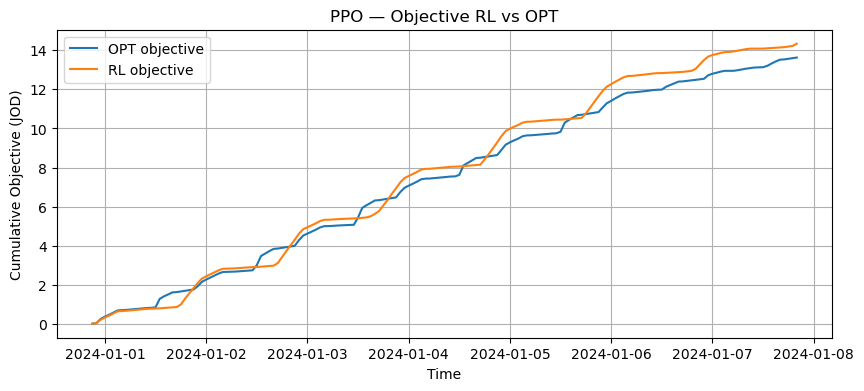

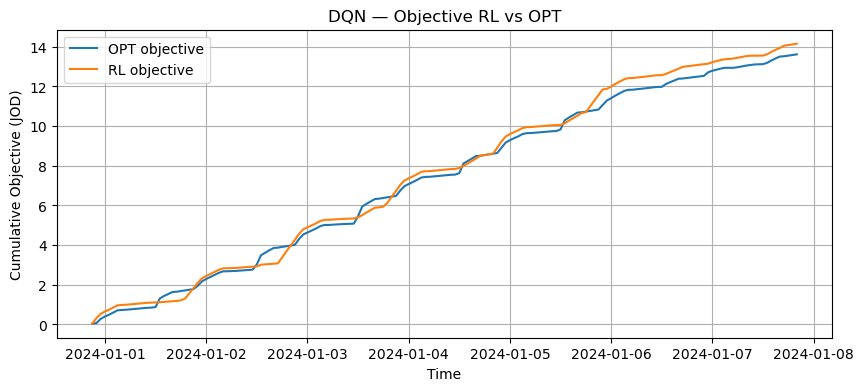

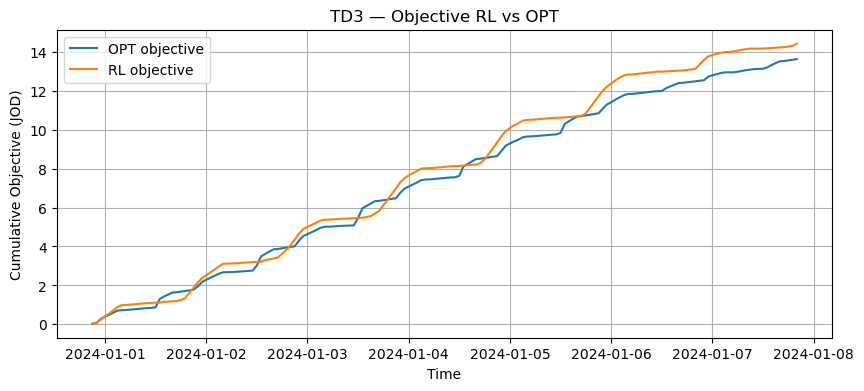

In [27]:
def plot_obj(m, title):
    plt.figure(figsize=(10,4))
    plt.plot(m["timestamp"], m["objective_cum_OPT"], label="OPT objective")
    plt.plot(m["timestamp"], m["objective_cum_RL"],  label="RL objective")
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Cumulative Objective (JOD)")
    plt.grid(True)
    plt.legend()
    plt.show()

plot_obj(m_ppo, "PPO — Objective RL vs OPT")
plot_obj(m_dqn, "DQN — Objective RL vs OPT")
plot_obj(m_td3, "TD3 — Objective RL vs OPT")


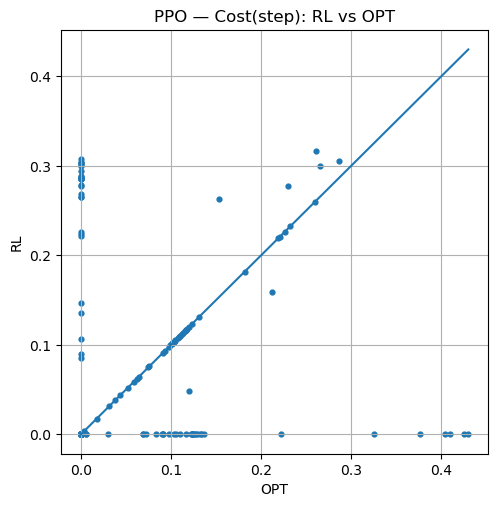

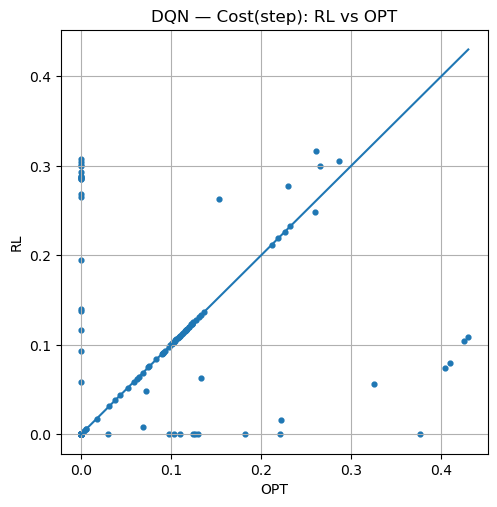

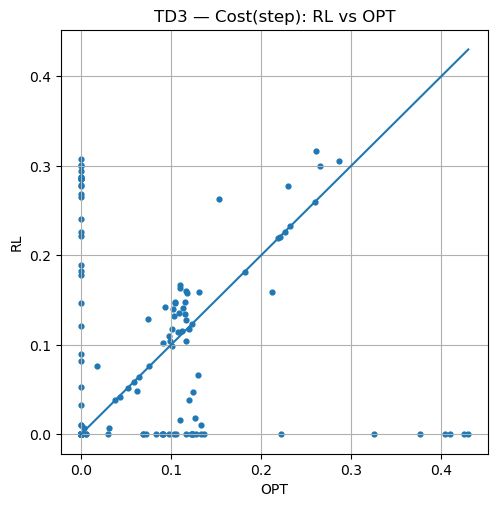

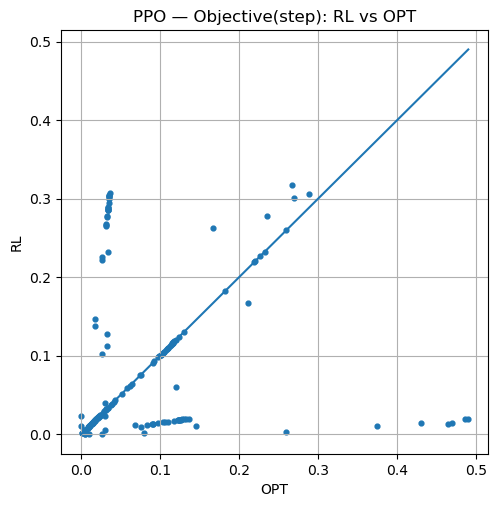

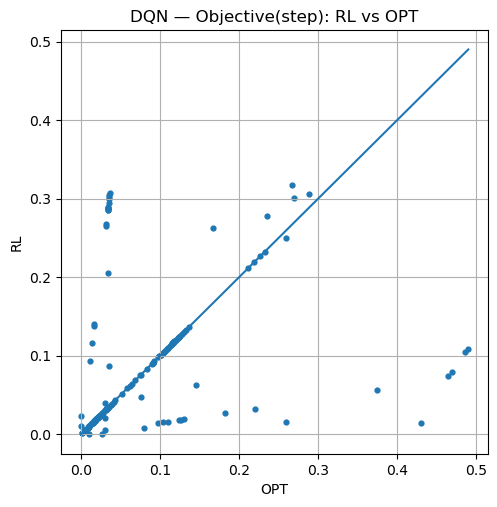

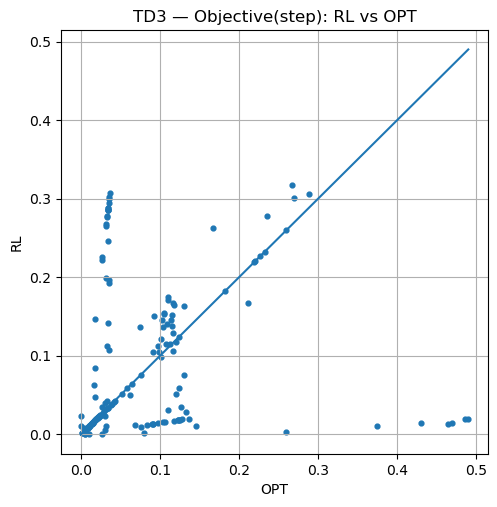

In [29]:
def scatter_rl_vs_opt(m, x_col, y_col, title):
    x = m[x_col].astype(float).values
    y = m[y_col].astype(float).values

    plt.figure(figsize=(5.5,5.5))
    plt.scatter(x, y, s=12)
    mn = min(x.min(), y.min())
    mx = max(x.max(), y.max())
    plt.plot([mn, mx], [mn, mx])  
    plt.title(title)
    plt.xlabel("OPT")
    plt.ylabel("RL")
    plt.grid(True)
    plt.show()


scatter_rl_vs_opt(m_ppo, "cost_JOD_OPT", "cost_JOD_RL", "PPO — Cost(step): RL vs OPT")
scatter_rl_vs_opt(m_dqn, "cost_JOD_OPT", "cost_JOD_RL", "DQN — Cost(step): RL vs OPT")
scatter_rl_vs_opt(m_td3, "cost_JOD_OPT", "cost_JOD_RL", "TD3 — Cost(step): RL vs OPT")


scatter_rl_vs_opt(m_ppo, "objective_step_OPT", "objective_step_RL", "PPO — Objective(step): RL vs OPT")
scatter_rl_vs_opt(m_dqn, "objective_step_OPT", "objective_step_RL", "DQN — Objective(step): RL vs OPT")
scatter_rl_vs_opt(m_td3, "objective_step_OPT", "objective_step_RL", "TD3 — Objective(step): RL vs OPT")


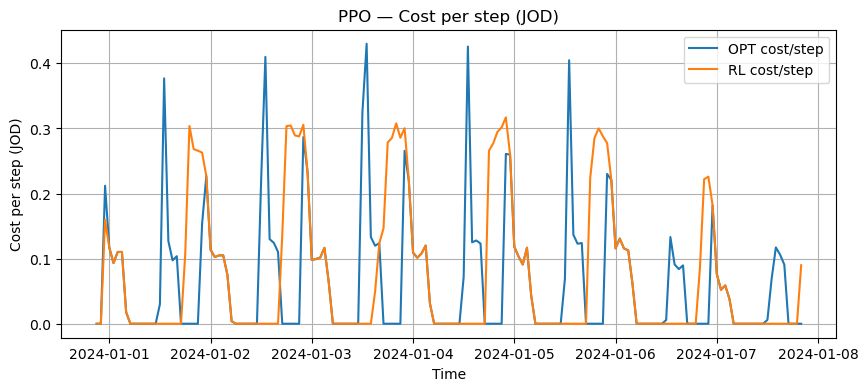

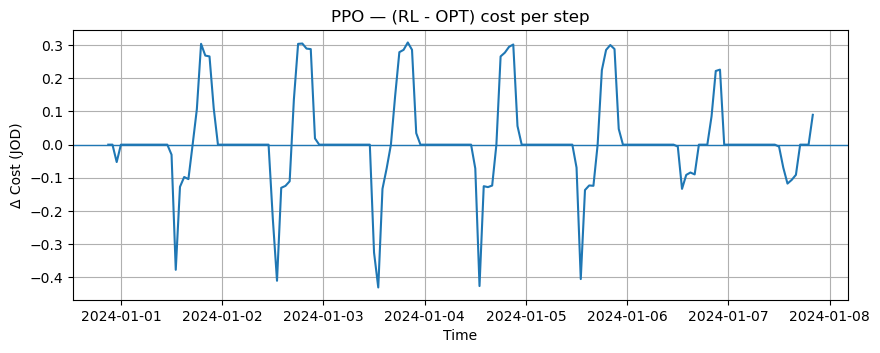

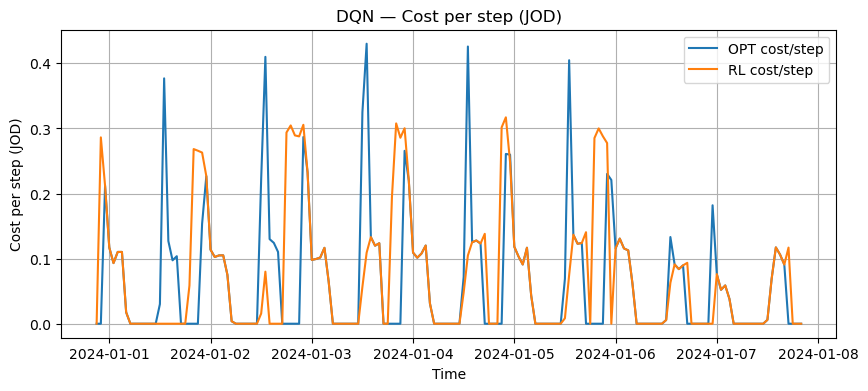

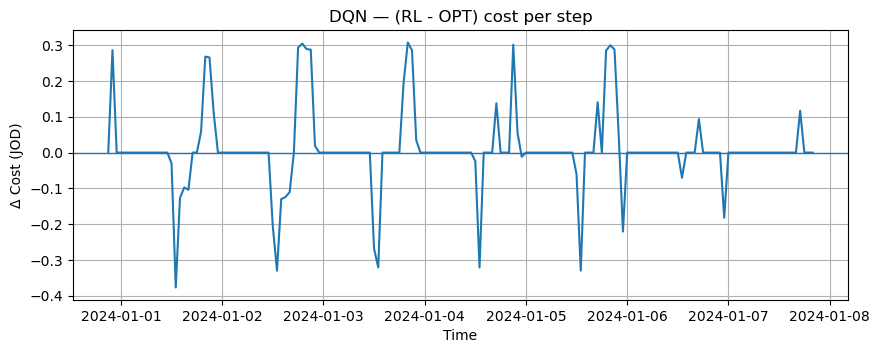

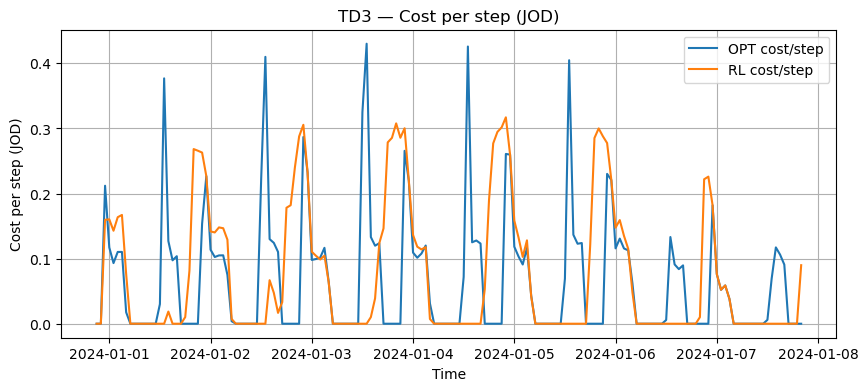

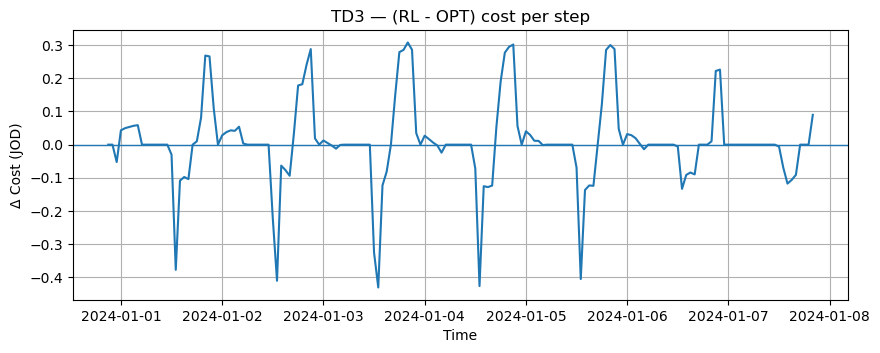

In [33]:
def plot_cost_step_and_diff(m, title):
    plt.figure(figsize=(10,4))
    plt.plot(m["timestamp"], m["cost_JOD_OPT"], label="OPT cost/step")
    plt.plot(m["timestamp"], m["cost_JOD_RL"],  label="RL cost/step")
    plt.title(title + " — Cost per step (JOD)")
    plt.xlabel("Time")
    plt.ylabel("Cost per step (JOD)")
    plt.grid(True)
    plt.legend()
    plt.show()

    diff = m["cost_JOD_RL"].astype(float) - m["cost_JOD_OPT"].astype(float)
    plt.figure(figsize=(10,3.5))
    plt.plot(m["timestamp"], diff)
    plt.axhline(0, linewidth=1)
    plt.title(title + " — (RL - OPT) cost per step")
    plt.xlabel("Time")
    plt.ylabel("Δ Cost (JOD)")
    plt.grid(True)
    plt.show()

plot_cost_step_and_diff(m_ppo, "PPO")
plot_cost_step_and_diff(m_dqn, "DQN")
plot_cost_step_and_diff(m_td3, "TD3")
